# Logistic Regression
- Can be understand using : Geometric inti and Perceptron trick

> Requirements
- We can only apply it on Linearly Separable Data or Can be separable by A Line

> Perceptron trick
- Here we take this eqn of line : Ax1 + Bx2 + Cx3 + d = 0 not normal eqn of line
- So here we need to find those vals of A,B,C using which we can classify the classes efficiently
- It is done as:
- First we take a random val which give us a random line
- Then we run a loop(generally 1000times) or convergence(till no misclassified pt left)
- And in each iteratn, select a rndom pt and check its classificatn -> if it's correct, leave it and if not -> then move line by changing A,B,C towards that pt 
And soon till loop completed and we get linearly separable line

> How to label region
- We can find which region of line is +ve or -ve using tool called desmos

> Transformations

<img src='img20.png'></img>
- let eqn be : Ax + By + c = 0
- How vals of A,B,c can change trnaformatn of line
- If we change val of c -> line move up or down
- If we change val of A -> line move from pt a to new pt but remain at same pt on b
- And same for chnage in val of B 

How it's done
- So if a -ve pt is present in +ve region -> then add 1 at last of its coordinate and substract them from coef of line
- And if a +ve pt in -ve region -> then add 1 at last of its coord but add them into coef of line
- And nothing change in line happen when +ve is present in +ve region and -ve present in -ve region
- NOTE : Gnerally we don't apply big transfomatn at once in ml -> So we multiply the pt coord with leaning rate and then add or substract a/c to need

> Algorithm

<img src='img21.png'></img>
<img src='img22.png'></img>

> Simplified algo

<img src='img23.png'></img>
- for i in range epochs
- select a rndom stud/pt(i)
- Wn = Wo + N(Yi - Yi^)Xi

In [1]:
from sklearn.datasets import make_classification
import numpy as np
X,y = make_classification(n_samples=100, n_features=2, n_informative=1, n_redundant=0, n_classes=2, n_clusters_per_class=1, random_state=41, hypercube=False, class_sep=30)

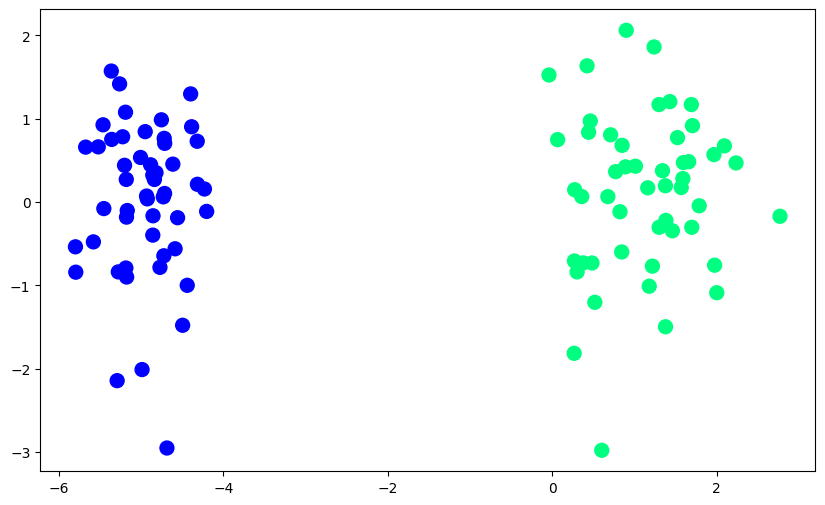

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(X[:,0], X[:,1], c=y, cmap='winter', s=100)

In [5]:
def perceptron(X,y):
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1

    for i in range (1000):
        j = np.random.randint(0,100)
        y_hat = step(np.dot(X[j], weights))
        weights = weights + lr*(y[j] - y_hat)*X[j]

    return weights[0], weights[1:]

In [3]:
def step(z):
    return 1 if z>0 else 0

In [7]:
intercept_, coef_ = perceptron(X, y)

In [8]:
print(coef_)
print(intercept_)

[1.1204053  0.40381514]
1.2000000000000002


> Problem in Perceptron trick wrt scikit learn implementn
- Line which we get usnig perceptron trick stops where we classified all pts correctly
- But using scikit implemented method, line improves itself and stop where we get best fit line or line which cut pts in symmetrical way -> Which reduce error

> Solution
- After selecting pt ->
- If it's misclassified -> Pull the line -> and if it's far away from line -> Magnitude of Pull will be high but if Close to line -> lesser mag of pull
- If it's not misclassified -> Push the line -> if pt is close to line -> Push will be High otherwise Push will be low for far pt
- THis will place line more correctly than previous way similar to scikit

# Sigmoid fn
<img src='img24.png'></img>
- Val of these fn always lies in between 0 & 1 and at 0, it's val is 0.5
- This fn scale down big no into range of 0 & 1
- Formula : a(z) = 1 / (1 + e^-z)
- Means: Yi^ = ~(z) where z = sigma(WiXi)

> How it's done ?
<img src='img25.png'></img>
- Here we cal sigma(WiXi) or z but instead of calulating it as z>=0 -> 1 and z<0 -> 0
- We pass val of z in sigmoid fn and if +ve val of z -> val is greater than 0.5 -> 1(true) 
- And if -ve val of z -> val is less than 0.5 -> 0(false)

> Use of sigmoid fn converts it into probabilitic fn which tells prob of happening and not happening something

> Impact of sigmoid
<img src='img26.png'></img>
- Using sigmoid fn, now (Yi - Yi^) never become zero which means there will be change in val of z everytime which helps in orieanting model line efficiently

> Still not perfect model while using sigmoid fn
- We does not get best fit or perfect line of model as we get when we use sklearn class but it is better from without using sigmoid

> TO get best fit line of model we use concept of Probability
- Maximum likelihood 
<img src='img27.png'></img>
- It also helps in comparing the best model between two models by comparing their prob product
-> Means multiplying the probabilities of respective class of individual pts and whose prob is high will be the better performing model
- So which model have high max likelihood will be the best model

- But here is problem as dataset have thousands of pt and we are multiplying prob which is in b/w 0 & 1 which make them uncomparable as they become too small 

- So for this we take log of the prob of every data pt and then add them up to make comparable

- But there is also a problem as log of val less than 1 is always -ve val

- So to solve this problem we find cross entropy of prob vals of data pts and try to minimise it where max likelihood need to be maximised
<img src='img28.png'></img>

> Cross entropy : summition of -ve log vals of maximum likelihood

> So that model will be best whose cross entropy is less
- for this we need to find loss fn for it
<img src='img29.png'></img>
- It is called as Log-loss error or Binary cross entropy fn
- We get a loss fn but it is not a closed form fn, so we can't get it's soln directly
- So we try to minimise it using Gradient descent

> Using scikit lr

In [3]:
from sklearn.linear_model import LogisticRegression
lor = LogisticRegression(penalty=None, solver='sag')
lor.fit(X,y)

C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",None
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

In [4]:
print(lor.coef_)
print(lor.intercept_)

[[3.5481146  0.13923293]]
[4.31329594]


In [5]:
m1 = -(lor.coef_[0][0] / lor.coef_[0][1])
b1 = -(lor.intercept_ / lor.coef_[0][1])

In [6]:
x_input = np.linspace(-3,3,100)
y_input = m1*x_input + b1

> Making LR from scratch using BatchGD

In [54]:
def Gd(X,y):
    X = np.insert(X,0,1,axis=1)
    wts = np.ones(X.shape[1])
    lr = 0.3

    for i in range(1000):
        y_hat = sigmoid(np.dot(X,wts))
        wts = wts + lr*(np.dot((y - y_hat), X) / X.shape[0])

    return wts[1:],wts[0]

In [55]:
def sigmoid(z):
    return 1/(1 + np.exp(-z))

In [56]:
coef_, intercept_ = Gd(X,y)

In [57]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [58]:
x_input1 = np.linspace(-3,3,100)
y_input1 = m*x_input + b

(-3.0, 2.0)

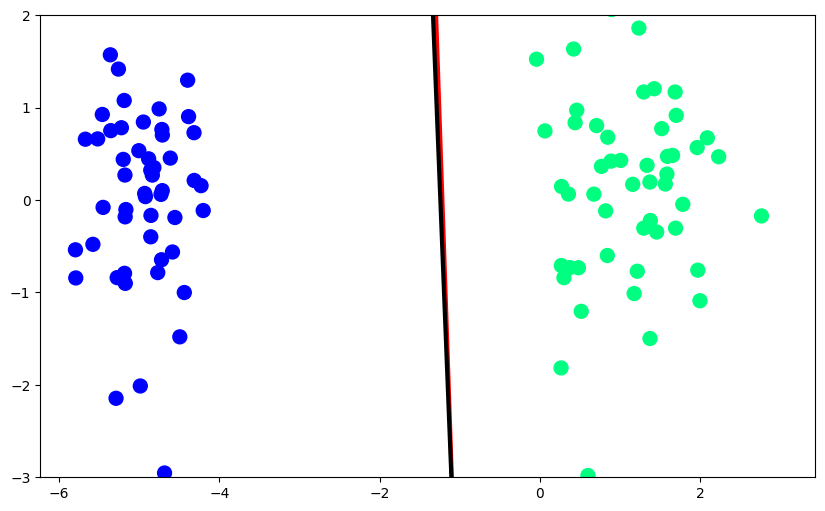

In [59]:
plt.figure(figsize=(10,6))
plt.plot(x_input, y_input, color='red', linewidth=3)
plt.plot(x_input1, y_input1, color='black', linewidth=3)
plt.scatter(X[:,0],X[:,1], c=y, cmap='winter', s=100)
plt.ylim(-3,2)